## QeFEM Test - TSP

In [1]:
from pathlib import Path
import gzip
import time
import math

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("SciPy not found. Hungarian decoder unavailable. Install scipy if needed.")

In [2]:
# ============================================================
# Cell 2: Device, dtype, and run settings
# ============================================================

device = torch.device("cpu")

dtype = torch.float64

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_REPLICAS = 32
N_STEPS = 1500
LOG_EVERY = 100

LR = 1e-2
LAMBDA_CITY = 50.0

BETA_MIN = 0.5
BETA_MAX = 100.0

GAMMA_MAX = 0.5
GAMMA_MIN = 0.0

USE_MIXER_ENERGY = True

BERLIN52_OPTIMUM = 7542
CLASSICAL_VANILLA_BEST = 9410.0

print("Device:", device)
print("dtype:", dtype)
print("Seed:", SEED)

print("\nRun settings:")
print("Replicas:", N_REPLICAS)
print("Steps:", N_STEPS)
print("Log every:", LOG_EVERY)

print("\nOptimization:")
print("LR:", LR)
print("LAMBDA_CITY:", LAMBDA_CITY)

print("\nAnnealing:")
print("BETA_MIN:", BETA_MIN)
print("BETA_MAX:", BETA_MAX)
print("GAMMA_MAX:", GAMMA_MAX)
print("GAMMA_MIN:", GAMMA_MIN)
print("USE_MIXER_ENERGY:", USE_MIXER_ENERGY)

print("\nBenchmarks:")
print("Berlin52 optimum:", BERLIN52_OPTIMUM)
print("Classical vanilla best:", CLASSICAL_VANILLA_BEST)

Device: cpu
dtype: torch.float64
Seed: 42

Run settings:
Replicas: 32
Steps: 1500
Log every: 100

Optimization:
LR: 0.01
LAMBDA_CITY: 50.0

Annealing:
BETA_MIN: 0.5
BETA_MAX: 100.0
GAMMA_MAX: 0.5
GAMMA_MIN: 0.0
USE_MIXER_ENERGY: True

Benchmarks:
Berlin52 optimum: 7542
Classical vanilla best: 9410.0


In [3]:
tsp_path = Path("berlin52.tsp.gz")

metadata = {}
coords_list = []
reading_coords = False

with gzip.open(tsp_path, "rt") as f:
    for line in f:
        line = line.strip()

        if line == "" or line == "EOF":
            continue

        if line == "NODE_COORD_SECTION":
            reading_coords = True
            continue

        if reading_coords:
            city_id, x, y = line.split()
            coords_list.append((int(city_id), float(x), float(y)))
        else:
            if ":" in line:
                key, value = line.split(":", 1)
                metadata[key.strip()] = value.strip()

# TSPLIB labels are 1-based.
# We sort by city id so internal index 0 corresponds to city label 1.
coords_list = sorted(coords_list, key=lambda row: row[0])

city_ids = [row[0] for row in coords_list]
coords = torch.tensor(
    [(row[1], row[2]) for row in coords_list],
    dtype=dtype
)

N = coords.shape[0]

print("Loaded:", tsp_path)
print("Metadata:", metadata)
print("Number of cities:", N)
print("First 5 city IDs:", city_ids[:5])
print("First 5 coordinates:")
print(coords[:5])

assert metadata["NAME"].lower() == "berlin52"
assert metadata["TYPE"] == "TSP"
assert int(metadata["DIMENSION"]) == 52
assert metadata["EDGE_WEIGHT_TYPE"] == "EUC_2D"
assert N == 52

Loaded: berlin52.tsp.gz
Metadata: {'NAME': 'berlin52', 'TYPE': 'TSP', 'COMMENT': '52 locations in Berlin (Groetschel)', 'DIMENSION': '52', 'EDGE_WEIGHT_TYPE': 'EUC_2D'}
Number of cities: 52
First 5 city IDs: [1, 2, 3, 4, 5]
First 5 coordinates:
tensor([[565., 575.],
        [ 25., 185.],
        [345., 750.],
        [945., 685.],
        [845., 655.]], dtype=torch.float64)


D_raw shape: torch.Size([52, 52])
D shape: torch.Size([52, 52])

Raw distances:
D_raw min: 0.0
D_raw max: 1716.0

Normalized distances:
D min: 0.0
D max: 1.0

Checks:
D_raw diagonal zero: True
D diagonal zero: True
D_raw symmetric: True
D symmetric: True


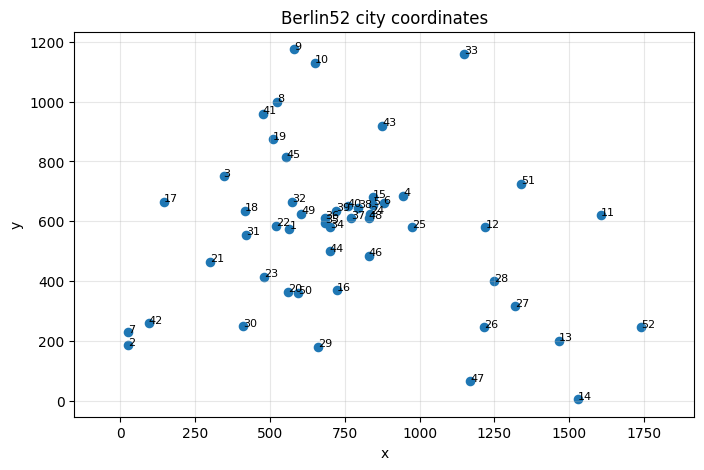

In [4]:
D_raw = torch.zeros((N, N), dtype=dtype)

for i in range(N):
    for j in range(N):
        if i == j:
            D_raw[i, j] = 0.0
        else:
            dx = coords[i, 0] - coords[j, 0]
            dy = coords[i, 1] - coords[j, 1]

            # TSPLIB EUC_2D convention for Berlin52:
            # nearest integer Euclidean distance
            D_raw[i, j] = round(math.sqrt(float(dx * dx + dy * dy)))

D_raw.fill_diagonal_(0.0)

D_max = D_raw.max()
D = D_raw / D_max

print("D_raw shape:", D_raw.shape)
print("D shape:", D.shape)

print("\nRaw distances:")
print("D_raw min:", D_raw.min().item())
print("D_raw max:", D_raw.max().item())

print("\nNormalized distances:")
print("D min:", D.min().item())
print("D max:", D.max().item())

print("\nChecks:")
print("D_raw diagonal zero:", torch.allclose(torch.diag(D_raw), torch.zeros(N, dtype=dtype)))
print("D diagonal zero:", torch.allclose(torch.diag(D), torch.zeros(N, dtype=dtype)))
print("D_raw symmetric:", torch.allclose(D_raw, D_raw.T))
print("D symmetric:", torch.allclose(D, D.T))

assert D_raw.shape == (N, N)
assert D.shape == (N, N)
assert torch.allclose(torch.diag(D_raw), torch.zeros(N, dtype=dtype))
assert torch.allclose(torch.diag(D), torch.zeros(N, dtype=dtype))
assert torch.allclose(D_raw, D_raw.T)
assert torch.allclose(D, D.T)
assert D_raw.max().item() > 0
assert torch.isclose(D.max(), torch.tensor(1.0, dtype=dtype))







plt.figure(figsize=(8, 5))

plt.scatter(coords[:, 0], coords[:, 1], s=35)

for idx in range(N):
    x = coords[idx, 0].item()
    y = coords[idx, 1].item()

    # Show TSPLIB 1-based city labels
    plt.text(x, y, str(idx + 1), fontsize=8)

plt.title("Berlin52 city coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Move tensors to device
coords = coords.to(device)
D = D.to(device)
D_raw = D_raw.to(device)

# ------------------------------------------------------------
# Trainable local diagonal energies
# ------------------------------------------------------------

A_INIT_SCALE = 1e-3

a = A_INIT_SCALE * torch.randn(
    N_REPLICAS,
    N,
    N,
    device=device,
    dtype=dtype,
    requires_grad=True
)

# ------------------------------------------------------------
# Distance-aware symmetric mixer
# ------------------------------------------------------------
#
# Old mixer:
#     complete graph with equal off-diagonal entries
#
# Problem:
#     massive eigenspace degeneracy -> unstable eigh backward.
#
# New mixer:
#     nearby cities mix more strongly than far cities.
#
# Construction:
#     K[c,d] = exp(-D[c,d] / tau), c != d
#     M = degree^{-1/2} K degree^{-1/2}
#     M = M / spectral_radius(M)
#
# This keeps M symmetric and removes the giant degeneracy.

MIXER_TAU = 0.25

K = torch.exp(-D / MIXER_TAU)
K.fill_diagonal_(0.0)

degree = K.sum(dim=1).clamp_min(1e-12)
degree_inv_sqrt = 1.0 / torch.sqrt(degree)

M = degree_inv_sqrt[:, None] * K * degree_inv_sqrt[None, :]

# Scale mixer so its spectral radius is 1.
# This makes gamma interpretable.
with torch.no_grad():
    M_evals = torch.linalg.eigvalsh(M)
    spectral_radius = M_evals.abs().max()

M = M / spectral_radius

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("a shape:", a.shape)
print("M shape:", M.shape)

print("\nParameter initialization:")
print("A_INIT_SCALE:", A_INIT_SCALE)
print("a min / mean / max:", a.min().item(), a.mean().item(), a.max().item())

print("\nDistance-aware mixer:")
print("MIXER_TAU:", MIXER_TAU)
print("M min / mean / max:", M.min().item(), M.mean().item(), M.max().item())
print("M diagonal mean:", torch.diag(M).mean().item())
print("M symmetric:", torch.allclose(M, M.T, atol=1e-10))

with torch.no_grad():
    evals_M = torch.linalg.eigvalsh(M)

print("\nMixer eigenvalues:")
print("min:", evals_M.min().item())
print("max:", evals_M.max().item())
print("spectral radius:", evals_M.abs().max().item())

assert a.shape == (N_REPLICAS, N, N)
assert M.shape == (N, N)
assert torch.allclose(torch.diag(M), torch.zeros(N, device=device, dtype=dtype), atol=1e-10)
assert torch.allclose(M, M.T, atol=1e-10)

a shape: torch.Size([32, 52, 52])
M shape: torch.Size([52, 52])

Parameter initialization:
A_INIT_SCALE: 0.001
a min / mean / max: -0.004186983940061262 -2.723587588883315e-06 0.004334191536544629

Distance-aware mixer:
MIXER_TAU: 0.25
M min / mean / max: 0.0 0.01877337676375116 0.09924100458884681
M diagonal mean: 0.0
M symmetric: True

Mixer eigenvalues:
min: -0.09945105152672241
max: 1.0000000000000004
spectral radius: 1.0000000000000004


In [6]:
def quantum_probs_entropy_mixer(a, M, beta, gamma):
    """
    Build local q-state quantum Gibbs states for every replica and tour slot.

    Local Hamiltonian:
        H[r,t] = diag(a[r,t]) - gamma * M

    Local density matrix:
        rho[r,t] = exp(-beta H[r,t]) / Tr exp(-beta H[r,t])

    Outputs:
        P[r,t,c]       = diagonal probability rho[r,t,c,c]
        S_Q[r]         = sum_t quantum entropy
        U_mixer[r]     = -gamma * sum_t Tr(rho[r,t] M)
        mixer_expect[r]= sum_t Tr(rho[r,t] M)
    """

    # H shape:
    # [R, N, N, N]
    #
    # dimensions:
    # R         = replicas
    # first N   = tour slots
    # last N,N  = local city-state Hamiltonian
    H = torch.diag_embed(a) - gamma * M

    # H is real symmetric, so use eigh.
    # evals shape: [R, N, N]
    # evecs shape: [R, N, N, N]
    #
    # evecs[..., :, k] is eigenvector k.
    evals, evecs = torch.linalg.eigh(H)

    # Gibbs eigenvalues of rho:
    # w_k = exp(-beta E_k) / sum_l exp(-beta E_l)
    weights = torch.softmax(-beta * evals, dim=-1)

    # ------------------------------------------------------------
    # Diagonal probabilities P = diag(rho)
    # ------------------------------------------------------------
    #
    # rho_cc = sum_k w_k * v_{c,k}^2
    P = torch.sum(
        (evecs ** 2) * weights.unsqueeze(-2),
        dim=-1
    )

    # ------------------------------------------------------------
    # Quantum entropy
    # ------------------------------------------------------------
    #
    # S = -sum_k w_k log w_k
    eps = 1e-12
    weights_safe = weights.clamp_min(eps)

    S_local = -(weights_safe * torch.log(weights_safe)).sum(dim=-1)

    # Sum entropy over tour slots
    S_Q = S_local.sum(dim=1)

    # ------------------------------------------------------------
    # Mixer expectation
    # ------------------------------------------------------------
    #
    # Tr(rho M)
    # =
    # sum_k w_k * v_k^T M v_k
    #
    # evecs shape: [R, N, city_component, eigenvector]
    #
    # M @ evecs applies M to every eigenvector.
    M_evecs = torch.matmul(M, evecs)

    # v_k^T M v_k for every eigenvector k
    vMv = (evecs * M_evecs).sum(dim=-2)

    # local mixer expectation per replica-slot
    mixer_expect_local = (weights * vMv).sum(dim=-1)

    # sum over tour slots
    mixer_expect = mixer_expect_local.sum(dim=1)

    # physical transverse/mixer energy contribution
    U_mixer = -gamma * mixer_expect

    return P, S_Q, U_mixer, mixer_expect

In [7]:
def expected_tour_length(P, D):
    """
    Expected normalized TSP tour length.

    P shape: [R, N, N]
        P[r, t, c] = probability that city c is assigned to slot t

    D shape: [N, N]
        normalized distance matrix

    Returns:
        U_tour shape: [R]
    """

    P_next = torch.roll(P, shifts=-1, dims=1)

    U_tour = torch.einsum(
        "rtc,cd,rtd->r",
        P,
        D,
        P_next
    )

    return U_tour


def city_penalty(P, lambda_city):
    """
    Penalize repeated/missing cities.

    Valid TSP constraint:
        sum_t P[r,t,c] = 1

    for every city c.
    """

    city_usage = P.sum(dim=1)

    U_city = lambda_city * ((city_usage - 1.0) ** 2).sum(dim=1)

    return U_city, city_usage


def quantum_tsp_free_energy(a, M, D, beta, gamma, lambda_city):
    """
    Corrected quantum TSP-FEM free energy.

    Local quantum state:
        H[r,t]   = diag(a[r,t]) - gamma * M
        rho[r,t] = exp(-beta H[r,t]) / Tr exp(-beta H[r,t])

    Probabilities:
        P[r,t,c] = rho[r,t,c,c]

    Free energy:
        F_Q =
            U_tour
            + U_city
            + U_mixer
            - S_Q / beta

    where:
        U_mixer = -gamma * sum_t Tr(rho[r,t] M)
    """

    P, S_Q, U_mixer, mixer_expect = quantum_probs_entropy_mixer(
        a=a,
        M=M,
        beta=beta,
        gamma=gamma
    )

    U_tour = expected_tour_length(
        P=P,
        D=D
    )

    U_city, city_usage = city_penalty(
        P=P,
        lambda_city=lambda_city
    )

    if USE_MIXER_ENERGY:
        F_Q = U_tour + U_city + U_mixer - S_Q / beta
    else:
        F_Q = U_tour + U_city - S_Q / beta

    return F_Q, U_tour, U_city, U_mixer, S_Q, mixer_expect, city_usage, P

In [8]:
beta0 = torch.tensor(BETA_MIN, device=device, dtype=dtype)
gamma0 = torch.tensor(GAMMA_MAX, device=device, dtype=dtype)

F_Q, U_tour, U_city, U_mixer, S_Q, mixer_expect, city_usage, P = quantum_tsp_free_energy(
    a=a,
    M=M,
    D=D,
    beta=beta0,
    gamma=gamma0,
    lambda_city=LAMBDA_CITY
)

print("Initial corrected quantum objective computed.")

print("\nShapes:")
print("F_Q:", F_Q.shape)
print("U_tour:", U_tour.shape)
print("U_city:", U_city.shape)
print("U_mixer:", U_mixer.shape)
print("S_Q:", S_Q.shape)
print("mixer_expect:", mixer_expect.shape)
print("city_usage:", city_usage.shape)
print("P:", P.shape)

print("\nInitial values:")
print("F_Q min / mean / max:", F_Q.min().item(), F_Q.mean().item(), F_Q.max().item())
print("U_tour min / mean / max:", U_tour.min().item(), U_tour.mean().item(), U_tour.max().item())
print("U_city min / mean / max:", U_city.min().item(), U_city.mean().item(), U_city.max().item())
print("U_mixer min / mean / max:", U_mixer.min().item(), U_mixer.mean().item(), U_mixer.max().item())
print("S_Q min / mean / max:", S_Q.min().item(), S_Q.mean().item(), S_Q.max().item())
print("mixer_expect min / mean / max:", mixer_expect.min().item(), mixer_expect.mean().item(), mixer_expect.max().item())

print("\nProbability check:")
print("slot sum min / mean / max:", P.sum(dim=2).min().item(), P.sum(dim=2).mean().item(), P.sum(dim=2).max().item())
print("city usage min / mean / max:", city_usage.min().item(), city_usage.mean().item(), city_usage.max().item())

print("\nInitial beta:", beta0.item())
print("Initial gamma:", gamma0.item())
print("USE_MIXER_ENERGY:", USE_MIXER_ENERGY)

# Basic assertions
assert F_Q.shape == (N_REPLICAS,)
assert U_tour.shape == (N_REPLICAS,)
assert U_city.shape == (N_REPLICAS,)
assert U_mixer.shape == (N_REPLICAS,)
assert S_Q.shape == (N_REPLICAS,)
assert mixer_expect.shape == (N_REPLICAS,)
assert city_usage.shape == (N_REPLICAS, N)
assert P.shape == (N_REPLICAS, N, N)

assert torch.allclose(
    P.sum(dim=2),
    torch.ones((N_REPLICAS, N), device=device, dtype=dtype),
    atol=1e-5
)

Initial corrected quantum objective computed.

Shapes:
F_Q: torch.Size([32])
U_tour: torch.Size([32])
U_city: torch.Size([32])
U_mixer: torch.Size([32])
S_Q: torch.Size([32])
mixer_expect: torch.Size([32])
city_usage: torch.Size([32, 52])
P: torch.Size([32, 52, 52])

Initial values:
F_Q min / mean / max: -393.9209190565421 -393.9207718959208 -393.92064415660064
U_tour min / mean / max: 17.09572586920496 17.095870554509574 17.09600448344232
U_city min / mean / max: 3.9463262161522645e-05 5.052357004031211e-05 5.9438391113564064e-05
U_mixer min / mean / max: -0.18083390932184873 -0.18083352737757075 -0.1808330454533462
S_Q min / mean / max: 205.41792943060688 205.41792972331137 205.41793026883067
mixer_expect min / mean / max: 0.3616660909066924 0.3616670547551415 0.36166781864369746

Probability check:
slot sum min / mean / max: 0.9999999999999993 1.0 1.0000000000000009
city usage min / mean / max: 0.9994519286489696 1.0 1.00034427808711

Initial beta: 0.5
Initial gamma: 0.5
USE_MIXER_E

In [9]:
assert SCIPY_AVAILABLE, "SciPy is needed for Hungarian decoding."

def decode_tour(P_single):
    """
    Decode one replica's soft assignment matrix into a valid TSP tour.

    P_single shape: [N, N]
        P_single[t, c] = probability that city c is assigned to slot t

    Returns:
        tour_1based: list of length N
            TSPLIB city labels, i.e. 1, 2, ..., N
    """

    P_np = P_single.detach().cpu().numpy()

    # Maximize sum_t P[t, city_t].
    # scipy solves minimization, so use -P.
    slot_ind, city_ind = linear_sum_assignment(-P_np)

    tour_internal = [None] * N

    for slot, city in zip(slot_ind, city_ind):
        tour_internal[slot] = int(city)

    # Convert internal 0-based city indices to TSPLIB 1-based city labels.
    tour_1based = [city + 1 for city in tour_internal]

    return tour_1based


def discrete_tour_length(tour_1based, D_raw):
    """
    Compute actual raw Berlin52 tour length.

    Input:
        tour_1based uses TSPLIB city labels.

    Internally:
        TSPLIB city label c -> tensor index c - 1
    """

    D_raw_cpu = D_raw.detach().cpu()

    length = 0.0

    for t in range(N):
        a_idx = tour_1based[t] - 1
        b_idx = tour_1based[(t + 1) % N] - 1

        length += D_raw_cpu[a_idx, b_idx].item()

    return length


# ------------------------------------------------------------
# Initial corrected quantum decoder test
# ------------------------------------------------------------

test_replica = torch.argmin(F_Q).item()

test_tour = decode_tour(P[test_replica])
test_length = discrete_tour_length(test_tour, D_raw)

test_gap = 100.0 * (test_length - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM

print("Test replica:", test_replica)
print("Decoded tour length:", len(test_tour))
print("Unique cities:", len(set(test_tour)))
print("Valid tour:", len(test_tour) == N and len(set(test_tour)) == N)

print("\nInitial corrected quantum decoded raw tour length:", test_length)
print("Initial gap vs Berlin52 optimum:", test_gap, "%")

print("\nDecoded tour in TSPLIB 1-based city labels:")
print(test_tour)

assert len(test_tour) == N
assert len(set(test_tour)) == N
assert min(test_tour) == 1
assert max(test_tour) == N

Test replica: 15
Decoded tour length: 52
Unique cities: 52
Valid tour: True

Initial corrected quantum decoded raw tour length: 31748.0
Initial gap vs Berlin52 optimum: 320.9493503049589 %

Decoded tour in TSPLIB 1-based city labels:
[18, 10, 50, 40, 31, 25, 38, 6, 16, 49, 34, 17, 26, 35, 42, 20, 11, 1, 3, 23, 28, 30, 13, 41, 39, 52, 24, 9, 29, 15, 5, 48, 22, 37, 14, 33, 43, 36, 32, 45, 2, 51, 47, 8, 7, 27, 4, 21, 19, 12, 46, 44]


Schedule type: exponential_beta

Schedule shapes:
temperature_schedule: torch.Size([1500])
beta_schedule: torch.Size([1500])
gamma_schedule: torch.Size([1500])

Temperature:
start: 2.0
end  : 0.009999999999999995

Beta:
start: 0.5
end  : 100.00000000000004

Gamma:
start: 0.5
end  : 0.0

Schedule probes:
step     0 | T     2.0000 | beta     0.5000 | gamma     0.5000
step   375 | T     0.5314 | beta     1.8820 | gamma     0.3749
step   750 | T     0.1412 | beta     7.0836 | gamma     0.2498
step  1125 | T     0.0375 | beta    26.6621 | gamma     0.1247
step  1499 | T     0.0100 | beta   100.0000 | gamma     0.0000


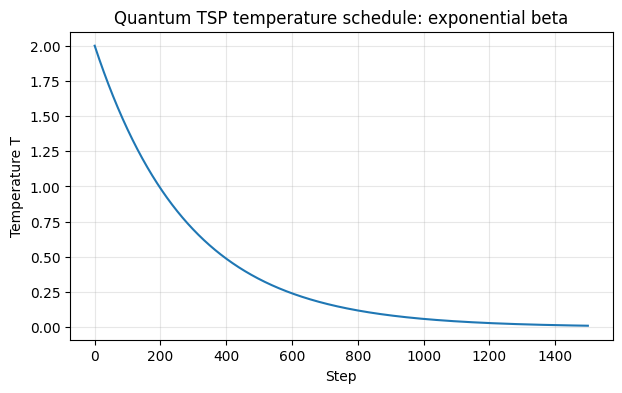

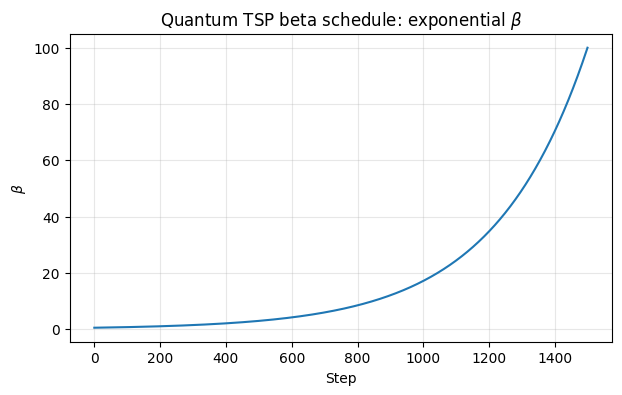

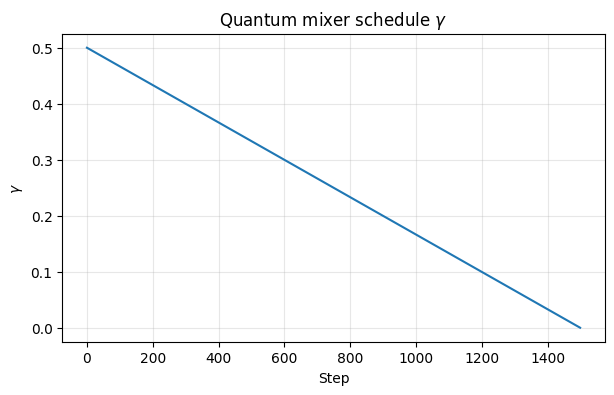

In [11]:
SCHEDULE_TYPE = "exponential_beta"

# ------------------------------------------------------------
# Exponential beta annealing
# ------------------------------------------------------------
#
# This is the correct choice when BETA_MIN is small.
#
# beta rises multiplicatively:
#     0.05 -> 100.0
#
# instead of staying tiny for most of the run.

beta_schedule = torch.exp(
    torch.linspace(
        math.log(BETA_MIN),
        math.log(BETA_MAX),
        N_STEPS,
        device=device,
        dtype=dtype
    )
)

temperature_schedule = 1.0 / beta_schedule

# ------------------------------------------------------------
# Gamma schedule
# ------------------------------------------------------------
#
# Mixer starts moderate and decays to zero.

gamma_schedule = torch.linspace(
    GAMMA_MAX,
    GAMMA_MIN,
    N_STEPS,
    device=device,
    dtype=dtype
)

print("Schedule type:", SCHEDULE_TYPE)

print("\nSchedule shapes:")
print("temperature_schedule:", temperature_schedule.shape)
print("beta_schedule:", beta_schedule.shape)
print("gamma_schedule:", gamma_schedule.shape)

print("\nTemperature:")
print("start:", temperature_schedule[0].item())
print("end  :", temperature_schedule[-1].item())

print("\nBeta:")
print("start:", beta_schedule[0].item())
print("end  :", beta_schedule[-1].item())

print("\nGamma:")
print("start:", gamma_schedule[0].item())
print("end  :", gamma_schedule[-1].item())

# ------------------------------------------------------------
# Inspect beta at important points
# ------------------------------------------------------------

probe_steps = [
    0,
    N_STEPS // 4,
    N_STEPS // 2,
    3 * N_STEPS // 4,
    N_STEPS - 1
]

print("\nSchedule probes:")
for s in probe_steps:
    print(
        f"step {s:5d} | "
        f"T {temperature_schedule[s].item():10.4f} | "
        f"beta {beta_schedule[s].item():10.4f} | "
        f"gamma {gamma_schedule[s].item():10.4f}"
    )

# ------------------------------------------------------------
# Plot temperature schedule
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(temperature_schedule.detach().cpu().numpy())
plt.title("Quantum TSP temperature schedule: exponential beta")
plt.xlabel("Step")
plt.ylabel("Temperature T")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot beta schedule
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(beta_schedule.detach().cpu().numpy())
plt.title(r"Quantum TSP beta schedule: exponential $\beta$")
plt.xlabel("Step")
plt.ylabel(r"$\beta$")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot gamma schedule
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(gamma_schedule.detach().cpu().numpy())
plt.title(r"Quantum mixer schedule $\gamma$")
plt.xlabel("Step")
plt.ylabel(r"$\gamma$")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Make sure a is a leaf tensor before giving it to Adam
a = a.detach().clone().requires_grad_(True)

optimizer = torch.optim.Adam([a], lr=LR)

# Since LR=5e-2 is aggressive, clip gradients.
GRAD_CLIP_NORM = 1.0

logs = []

start_time = time.time()

iterator = range(N_STEPS)
if tqdm is not None:
    iterator = tqdm(iterator)

best_seen_length = float("inf")
best_seen_tour = None
best_seen_replica = None

for step in iterator:
    beta = beta_schedule[step]
    gamma = gamma_schedule[step]

    optimizer.zero_grad()

    F_Q, U_tour, U_city, U_mixer, S_Q, mixer_expect, city_usage, P = quantum_tsp_free_energy(
        a=a,
        M=M,
        D=D,
        beta=beta,
        gamma=gamma,
        lambda_city=LAMBDA_CITY
    )

    loss = F_Q.mean()

    if not torch.isfinite(loss):
        print("Non-finite loss detected at step:", step)
        print("loss:", loss.item())
        break

    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        [a],
        max_norm=GRAD_CLIP_NORM
    )

    optimizer.step()

    

    # Keep trainable diagonal energies bounded.
    # This helps prevent eigendecomposition / softmax instability.
    with torch.no_grad():
        a.clamp_(-20.0, 20.0)

    # --------------------------------------------------------
    # Logging and discrete decoding
    # --------------------------------------------------------
    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        with torch.no_grad():
            F_eval, U_eval, U_city_eval, U_mixer_eval, S_eval, mixer_expect_eval, city_usage_eval, P_eval = quantum_tsp_free_energy(
                a=a,
                M=M,
                D=D,
                beta=beta,
                gamma=gamma,
                lambda_city=LAMBDA_CITY
            )

            current_best_length = float("inf")
            current_best_tour = None
            current_best_replica = None

            for r in range(N_REPLICAS):
                tour_r = decode_tour(P_eval[r])
                length_r = discrete_tour_length(tour_r, D_raw)

                if length_r < current_best_length:
                    current_best_length = length_r
                    current_best_tour = tour_r
                    current_best_replica = r

            if current_best_length < best_seen_length:
                best_seen_length = current_best_length
                best_seen_tour = current_best_tour
                best_seen_replica = current_best_replica

            city_violation = torch.abs(city_usage_eval - 1.0)

            gap_percent = 100.0 * (best_seen_length - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM

            log_row = {
                "step": step,
                "temperature": (1.0 / beta).item(),
                "beta": beta.item(),
                "gamma": gamma.item(),
                "loss": loss.item(),
                "grad_norm": float(grad_norm),

                "F_Q_min": F_eval.min().item(),
                "F_Q_mean": F_eval.mean().item(),

                "U_tour_min": U_eval.min().item(),
                "U_tour_mean": U_eval.mean().item(),

                "U_city_min": U_city_eval.min().item(),
                "U_city_mean": U_city_eval.mean().item(),

                "U_mixer_min": U_mixer_eval.min().item(),
                "U_mixer_mean": U_mixer_eval.mean().item(),

                "S_Q_mean": S_eval.mean().item(),
                "mixer_expect_mean": mixer_expect_eval.mean().item(),

                "city_violation_mean": city_violation.mean().item(),
                "city_violation_max": city_violation.max().item(),

                "current_best_length": current_best_length,
                "current_best_replica": current_best_replica,

                "best_seen_length": best_seen_length,
                "best_seen_replica": best_seen_replica,
                "gap_percent": gap_percent,

                "elapsed_sec": time.time() - start_time,
            }

            logs.append(log_row)

            print(
                f"step {step:5d} | "
                f"T {(1.0 / beta).item():8.4f} | "
                f"beta {beta.item():8.4f} | "
                f"gamma {gamma.item():8.4f} | "
                f"F_min {F_eval.min().item():10.4f} | "
                f"U_min {U_eval.min().item():8.4f} | "
                f"Uc_min {U_city_eval.min().item():8.4f} | "
                f"Umix_mean {U_mixer_eval.mean().item():9.4f} | "
                f"S_mean {S_eval.mean().item():8.4f} | "
                f"best raw {best_seen_length:8.1f} | "
                f"gap {gap_percent:7.2f}%"
            )

logs_df = pd.DataFrame(logs)

# ------------------------------------------------------------
# Final quantum state after training
# ------------------------------------------------------------

with torch.no_grad():
    beta_final = beta_schedule[-1]
    gamma_final = gamma_schedule[-1]

    F_Q, U_tour, U_city, U_mixer, S_Q, mixer_expect, city_usage, P = quantum_tsp_free_energy(
        a=a,
        M=M,
        D=D,
        beta=beta_final,
        gamma=gamma_final,
        lambda_city=LAMBDA_CITY
    )

step     0 | T   2.0000 | beta   0.5000 | gamma   0.5000 | F_min  -393.9022 | U_min  17.0510 | Uc_min   0.0620 | Umix_mean   -0.1809 | S_mean 205.4173 | best raw  26857.0 | gap  256.10%
step   100 | T   1.4045 | beta   0.7120 | gamma   0.4666 | F_min  -271.6031 | U_min  17.0744 | Uc_min   0.0109 | Umix_mean   -0.2323 | S_mean 205.3782 | best raw  25545.0 | gap  238.70%
step   200 | T   0.9863 | beta   1.0139 | gamma   0.4333 | F_min  -185.7104 | U_min  17.0733 | Uc_min   0.0102 | Umix_mean   -0.2986 | S_mean 205.3042 | best raw  25545.0 | gap  238.70%
step   300 | T   0.6927 | beta   1.4437 | gamma   0.3999 | F_min  -125.4070 | U_min  17.0723 | Uc_min   0.0106 | Umix_mean   -0.3848 | S_mean 205.1650 | best raw  25545.0 | gap  238.70%
step   400 | T   0.4864 | beta   2.0558 | gamma   0.3666 | F_min   -83.0774 | U_min  17.0685 | Uc_min   0.0116 | Umix_mean   -0.4981 | S_mean 204.9002 | best raw  24298.0 | gap  222.17%
step   500 | T   0.3416 | beta   2.9275 | gamma   0.3332 | F_min   -53

In [13]:
print("\nCorrected quantum training finished.")
print("Best raw tour length seen:", best_seen_length)
print("Best replica:", best_seen_replica)
print("Gap vs Berlin52 optimum 7542:", 100.0 * (best_seen_length - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM, "%")
print("Classical vanilla best:", CLASSICAL_VANILLA_BEST)
print("Difference from classical vanilla:", best_seen_length - CLASSICAL_VANILLA_BEST)

print("\nBest corrected quantum tour in TSPLIB 1-based city labels:")
print(best_seen_tour)


Corrected quantum training finished.
Best raw tour length seen: 9314.0
Best replica: 0
Gap vs Berlin52 optimum 7542: 23.49509413948555 %
Classical vanilla best: 9410.0
Difference from classical vanilla: -96.0

Best corrected quantum tour in TSPLIB 1-based city labels:
[38, 24, 5, 15, 43, 33, 51, 11, 26, 47, 14, 52, 13, 27, 28, 12, 25, 4, 6, 48, 40, 39, 36, 35, 49, 32, 19, 8, 10, 9, 41, 45, 3, 18, 31, 17, 42, 7, 2, 30, 21, 23, 22, 20, 1, 50, 29, 16, 44, 34, 46, 37]


In [15]:
# ============================================================
# Cell 13: Corrected quantum inference after training
# ============================================================

with torch.no_grad():
    beta_final = beta_schedule[-1]
    gamma_final = gamma_schedule[-1]

    F_final, U_tour_final, U_city_final, U_mixer_final, S_final, mixer_expect_final, city_usage_final, P_final = quantum_tsp_free_energy(
        a=a,
        M=M,
        D=D,
        beta=beta_final,
        gamma=gamma_final,
        lambda_city=LAMBDA_CITY
    )

    inference_rows = []

    for r in range(N_REPLICAS):
        tour_r = decode_tour(P_final[r])
        length_r = discrete_tour_length(tour_r, D_raw)

        valid_r = (len(tour_r) == N) and (len(set(tour_r)) == N)

        slot_max_probs = P_final[r].max(dim=1).values

        inference_rows.append({
            "replica": r,
            "raw_tour_length": length_r,
            "gap_percent": 100.0 * (length_r - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM,
            "delta_vs_classical": length_r - CLASSICAL_VANILLA_BEST,
            "valid_tour": valid_r,

            "F_Q": F_final[r].item(),
            "U_tour_normalized": U_tour_final[r].item(),
            "U_city": U_city_final[r].item(),
            "U_mixer": U_mixer_final[r].item(),
            "S_Q": S_final[r].item(),
            "mixer_expect": mixer_expect_final[r].item(),

            "mean_slot_max_prob": slot_max_probs.mean().item(),
            "min_slot_max_prob": slot_max_probs.min().item(),
            "max_slot_max_prob": slot_max_probs.max().item(),

            "tour_1based": tour_r,
        })

inference_df = pd.DataFrame(inference_rows)
inference_df = inference_df.sort_values("raw_tour_length").reset_index(drop=True)

best_row = inference_df.iloc[0]

best_final_replica = int(best_row["replica"])
best_final_length = float(best_row["raw_tour_length"])
best_final_gap = float(best_row["gap_percent"])
best_final_delta_vs_classical = float(best_row["delta_vs_classical"])
best_final_tour = best_row["tour_1based"]

print("Corrected quantum inference finished.")

print("\nFinal schedule values:")
print("Final beta:", beta_final.item())
print("Final temperature:", (1.0 / beta_final).item())
print("Final gamma:", gamma_final.item())

print("\nBest final corrected quantum result:")
print("Best final replica:", best_final_replica)
print("Best final raw tour length:", best_final_length)
print("Gap vs Berlin52 optimum 7542:", best_final_gap, "%")
print("Classical vanilla best:", CLASSICAL_VANILLA_BEST)
print("Delta vs classical vanilla:", best_final_delta_vs_classical)
print("Valid tour:", bool(best_row["valid_tour"]))

print("\nBest final corrected quantum objective values:")
print("F_Q:", best_row["F_Q"])
print("U_tour_normalized:", best_row["U_tour_normalized"])
print("U_city:", best_row["U_city"])
print("U_mixer:", best_row["U_mixer"])
print("S_Q:", best_row["S_Q"])
print("mixer_expect:", best_row["mixer_expect"])

print("\nBest final assignment sharpness:")
print("mean_slot_max_prob:", best_row["mean_slot_max_prob"])
print("min_slot_max_prob:", best_row["min_slot_max_prob"])
print("max_slot_max_prob:", best_row["max_slot_max_prob"])

print("\nBest final corrected quantum tour in TSPLIB 1-based city labels:")
print(best_final_tour)

print("\nTop 10 corrected quantum replicas by decoded raw tour length:")
display(
    inference_df[
        [
            "replica",
            "raw_tour_length",
            "gap_percent",
            "delta_vs_classical",
            "valid_tour",
            "F_Q",
            "U_tour_normalized",
            "U_city",
            "U_mixer",
            "S_Q",
            "mean_slot_max_prob",
        ]
    ].head(10)
)

Corrected quantum inference finished.

Final schedule values:
Final beta: 100.00000000000004
Final temperature: 0.009999999999999995
Final gamma: 0.0

Best final corrected quantum result:
Best final replica: 0
Best final raw tour length: 9314.0
Gap vs Berlin52 optimum 7542: 23.49509413948555 %
Classical vanilla best: 9410.0
Delta vs classical vanilla: -96.0
Valid tour: True

Best final corrected quantum objective values:
F_Q: 6.381476671348621
U_tour_normalized: 6.94772497937201
U_city: 0.5673475829356847
U_mixer: -0.0
S_Q: 113.35958909590741
mixer_expect: 0.0

Best final assignment sharpness:
mean_slot_max_prob: 0.30676408219466594
min_slot_max_prob: 0.07824551773751956
max_slot_max_prob: 0.8994855446250254

Best final corrected quantum tour in TSPLIB 1-based city labels:
[38, 24, 5, 15, 43, 33, 51, 11, 26, 47, 14, 52, 13, 27, 28, 12, 25, 4, 6, 48, 40, 39, 36, 35, 49, 32, 19, 8, 10, 9, 41, 45, 3, 18, 31, 17, 42, 7, 2, 30, 21, 23, 22, 20, 1, 50, 29, 16, 44, 34, 46, 37]

Top 10 correcte

,replica,raw_tour_length,gap_percent,delta_vs_classical,valid_tour,F_Q,U_tour_normalized,U_city,U_mixer,S_Q,mean_slot_max_prob
0,0,9314.0,23.495094,-96.0,True,6.381477,6.947725,0.567348,-0.0,113.359589,0.306764
1,15,9841.0,30.482631,431.0,True,10.632163,7.490399,4.341534,-0.0,119.977003,0.298996
2,13,10080.0,33.651551,670.0,True,13.031479,6.993951,7.104257,-0.0,106.672916,0.348899
3,1,10195.0,35.176346,785.0,True,15.558975,7.319416,9.417949,-0.0,117.839013,0.311915
4,4,10527.0,39.578361,1117.0,True,12.655722,7.521072,6.207234,-0.0,107.258464,0.370513
5,24,10613.0,40.718642,1203.0,True,7.271523,8.367503,0.191890,-0.0,128.786937,0.261557
6,8,10618.0,40.784938,1208.0,True,7.771951,8.311344,0.757739,-0.0,129.713246,0.239334
7,26,10663.0,41.381596,1253.0,True,7.358168,8.307330,0.385855,-0.0,133.501766,0.219220
8,12,10667.0,41.434633,1257.0,True,8.710902,7.570742,2.343601,-0.0,120.344046,0.286138
9,2,10685.0,41.673296,1275.0,True,7.376913,7.934940,0.735026,-0.0,129.305295,0.231108


In [16]:
# ============================================================
# Cell 14: Compare corrected quantum vs vanilla FEM and optimum
# ============================================================

comparison_rows = [
    {
        "method": "Berlin52 optimum",
        "raw_tour_length": BERLIN52_OPTIMUM,
        "gap_percent": 0.0,
        "delta_vs_optimum": 0.0,
        "delta_vs_vanilla": BERLIN52_OPTIMUM - CLASSICAL_VANILLA_BEST,
    },
    {
        "method": "Vanilla FEM",
        "raw_tour_length": CLASSICAL_VANILLA_BEST,
        "gap_percent": 100.0 * (CLASSICAL_VANILLA_BEST - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM,
        "delta_vs_optimum": CLASSICAL_VANILLA_BEST - BERLIN52_OPTIMUM,
        "delta_vs_vanilla": 0.0,
    },
    {
        "method": "Corrected quantum TSP-FEM",
        "raw_tour_length": best_final_length,
        "gap_percent": best_final_gap,
        "delta_vs_optimum": best_final_length - BERLIN52_OPTIMUM,
        "delta_vs_vanilla": best_final_length - CLASSICAL_VANILLA_BEST,
    },
]

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

quantum_improvement_raw = CLASSICAL_VANILLA_BEST - best_final_length
quantum_improvement_percent_vs_vanilla = 100.0 * quantum_improvement_raw / CLASSICAL_VANILLA_BEST

print("Corrected quantum improvement over vanilla:")
print("Raw improvement:", quantum_improvement_raw)
print("Percent improvement vs vanilla:", quantum_improvement_percent_vs_vanilla, "%")

print("\nGap comparison:")
print("Vanilla gap:", comparison_df.loc[comparison_df["method"] == "Vanilla FEM", "gap_percent"].iloc[0], "%")
print("Corrected quantum gap:", best_final_gap, "%")
print("Gap reduction:", comparison_df.loc[comparison_df["method"] == "Vanilla FEM", "gap_percent"].iloc[0] - best_final_gap, "percentage points")

,method,raw_tour_length,gap_percent,delta_vs_optimum,delta_vs_vanilla
0,Berlin52 optimum,7542.0,0.000000,0.0,-1868.0
1,Vanilla FEM,9410.0,24.767966,1868.0,0.0
2,Corrected quantum TSP-FEM,9314.0,23.495094,1772.0,-96.0


Corrected quantum improvement over vanilla:
Raw improvement: 96.0
Percent improvement vs vanilla: 1.0201912858661 %

Gap comparison:
Vanilla gap: 24.76796605674887 %
Corrected quantum gap: 23.49509413948555 %
Gap reduction: 1.2728719172633234 percentage points
